<a href="https://colab.research.google.com/github/MishterBluesky/CoEVFold/blob/main/Co_EVFold_Heteromer_plmc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  CoEVFold Heteromer &mdash; plmc (EVcouplings) backend 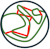

This notebook, derived from MMSEQ2, GREMLIN and ColabFold, performs a GREMLIN direct coupling analysis of coevolution on an input structure, and then plots this against the structure to see the level of coevolution agreement.

**Simply upload the .pdb file, select your cutoffs and away!**

Remember, coevolution whilst routed in genetic history is not an absolute sign that your proteins interact! However if this is shown in multiple instances, by alphafold and has agreement that indicates the interactions are more likely.

The output is in the form of a heatmap of coevolution, as well as a .pse file with connections between proteins output as red lines. Limit of 1000a.a combined gene lengths. Note: Selecting A100 GPU High RAM allows for up to 2500a.a combined gene lengths

## Coupling-inference backend: plmc / EVcouplings

This notebook is a variant of the original **CoEVFold Heteromer** pipeline
(`MSA → GREMLIN/MRF → coupling matrix → CoEVFold`), with the coupling-inference
step swapped out for **plmc / EVcouplings**. Everything upstream (MSA generation) and
downstream (from the point CoEVFold has its residue-pair matrix onward,
i.e. building `pd_mtx`/`coev_mtx` and everything after) is **identical** to
the GREMLIN notebook -- only the cells between "Number of effective
sequences" and "`mtx = ...`" have been replaced.

**Source:** [debbiemarkslab/plmc](https://github.com/debbiemarkslab/plmc), the coupling-inference program underneath the EVcouplings pipeline. We only use `bin/plmc` itself, not the rest of the EVcouplings workflow (alignment building, PDB search, etc. -- all of that is already handled by the existing CoEVFold MSA/PDB cells).

plmc is run on the *same* gap-filtered alignment (>=50% gap columns removed, `mk_msa`'s `v_idx`) that GREMLIN/CCMpred use, for a fair comparison.

**Caveat:** plmc's `-c` couplings file only reports the final APC-corrected Frobenius-norm score per pair (see the plmc README) -- the pre-APC value isn't written out anywhere accessible without parsing its binary parameter file. So below, the common matrix format's `raw` column is simply set equal to the APC-corrected value for this backend; only `apc`/`zscore` (what the downstream thresholding actually uses) carry real, distinct information.


In [ ]:
%%time
#@title setup
unified_memory = True #@param {type:"boolean"}
import os, time, gc
if unified_memory:
  ENV = {"TF_FORCE_UNIFIED_MEMORY":"1", "XLA_PYTHON_CLIENT_MEM_FRACTION":"4.0"}
  for k,v in ENV.items(): os.environ[k] = v
if not os.path.isdir("params"):
  # get code
  print("installing ColabDesign")
  os.system("(mkdir params; apt-get install aria2 -qq; \
  aria2c -q -x 16 https://storage.googleapis.com/alphafold/alphafold_params_2022-12-06.tar; \
  tar -xf alphafold_params_2022-12-06.tar -C params; touch params/done.txt )&")

  os.system("pip -q install git+https://github.com/sokrypton/ColabDesign.git@gamma")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/colabdesign colabdesign")
  os.system("wget https://raw.githubusercontent.com/sokrypton/ColabFold/main/colabfold/colabfold.py -O colabfold_utils.py")
  #os.system("wget https://raw.githubusercontent.com/sokrypton/ColabFold/beta/colabfold/mmseqs/api.py")

  # install hhsuite
  print("installing HHsuite")
  os.makedirs("hhsuite", exist_ok=True)
  os.system(f"curl -fsSL https://github.com/soedinglab/hh-suite/releases/download/v3.3.0/hhsuite-3.3.0-SSE2-Linux.tar.gz | tar xz -C hhsuite/")

  # download params
  if not os.path.isfile("params/done.txt"):
    print("downloading AlphaFold params")
    while not os.path.isfile("params/done.txt"):
      time.sleep(5)
if "hhsuite" not in os.environ['PATH']:
  os.environ['PATH'] += ":hhsuite/bin:hhsuite/scripts"

import re, tempfile
from IPython.display import HTML
from google.colab import files
import numpy as np
from colabdesign import mk_af_model, clear_mem
from colabdesign.af.contrib import predict
from colabdesign.af.contrib.cyclic import add_cyclic_offset
from colabdesign.shared.protein import _np_rmsd, _np_kabsch
from colabdesign.shared.plot import plot_pseudo_3D, pymol_cmap


import jax
import jax.numpy as jnp
from colabfold_utils import run_mmseqs2
import matplotlib.pyplot as plt
import string
import numpy as np

def clear_mem():
  backend = jax.lib.xla_bridge.get_backend()
  for buf in backend.live_buffers(): buf.delete()

def get_pdb(pdb_code=""):
  if pdb_code is None or pdb_code == "":
    upload_dict = files.upload()
    pdb_string = upload_dict[list(upload_dict.keys())[0]]
    with open("tmp.pdb","wb") as out: out.write(pdb_string)
    return "tmp.pdb"
  elif os.path.isfile(pdb_code):
    return pdb_code
  elif len(pdb_code) == 4:
    os.makedirs("tmp",exist_ok=True)
    os.system(f"wget -qnc https://files.rcsb.org/download/{pdb_code}.cif -P tmp/")
    return f"tmp/{pdb_code}.cif"
  else:
    os.makedirs("tmp",exist_ok=True)
    os.system(f"wget -qnc https://alphafold.ebi.ac.uk/files/AF-{pdb_code}-F1-model_v4.pdb -P tmp/")
    return f"tmp/AF-{pdb_code}-F1-model_v4.pdb"

def run_hhalign(query_sequence, target_sequence, query_a3m=None, target_a3m=None):
  with tempfile.NamedTemporaryFile() as tmp_query, \
  tempfile.NamedTemporaryFile() as tmp_target, \
  tempfile.NamedTemporaryFile() as tmp_alignment:
    if query_a3m is None:
      tmp_query.write(f">Q\n{query_sequence}\n".encode())
      tmp_query.flush()
      query_a3m = tmp_query.name
    if target_a3m is None:
      tmp_target.write(f">T\n{target_sequence}\n".encode())
      tmp_target.flush()
      target_a3m = tmp_target.name
    os.system(f"hhalign -hide_cons -i {query_a3m} -t {target_a3m} -o {tmp_alignment.name}")
    X, start_indices = predict.parse_hhalign_output(tmp_alignment.name)
  return X, start_indices

def run_do_not_align(query_sequence, target_sequence, **arg):
  return [query_sequence,target_sequence],[0,0]

def run_hhfilter(input, output, id=90, qid=10):
  os.system(f"hhfilter -id {id} -qid {qid} -i {input} -o {output}")

@jax.jit
def get_coevolution(X):
  '''given one-hot encoded MSA, return contacts'''
  Y = jax.nn.one_hot(X,22)
  N,L,A = Y.shape
  Y_flat = Y.reshape(N,-1)
  # covariance
  c = jnp.cov(Y_flat.T)

  # inverse covariance
  shrink = 4.5/jnp.sqrt(N) * jnp.eye(c.shape[0])
  ic = jnp.linalg.inv(c + shrink)

  # partial correlation coefficient
  ic_diag = jnp.diag(ic)
  pcc = ic / jnp.sqrt(ic_diag[:,None] * ic_diag[None,:])

  raw = jnp.sqrt(jnp.square(pcc.reshape(L,A,L,A)[:,:20,:,:20]).sum((1,3)))
  i = jnp.arange(L)
  raw = raw.at[i,i].set(0)
  # do apc
  ap = raw.sum(0,keepdims=True) * raw.sum(1,keepdims=True) / raw.sum()
  return (raw - ap).at[i,i].set(0)

def plot_3D(aux, Ls, file_name, show=False):
  plt.figure(figsize=(10,5))
  xyz = aux["atom_positions"][:,1]
  xyz = xyz @ _np_kabsch(xyz, xyz, return_v=True, use_jax=False)
  ax = plt.subplot(1,2,1)
  if len(Ls) > 1:
    plt.title("chain")
    c = np.concatenate([[n]*L for n,L in enumerate(Ls)])
    plot_pseudo_3D(xyz=xyz, c=c, cmap=pymol_cmap, cmin=0, cmax=39, Ls=Ls, ax=ax)
  else:
    plt.title("length")
    plot_pseudo_3D(xyz=xyz, Ls=Ls, ax=ax)
  plt.axis(False)
  ax = plt.subplot(1,2,2)
  plt.title("plddt")
  plot_pseudo_3D(xyz=xyz, c=aux["plddt"], cmin=0.5, cmax=0.9, Ls=Ls, ax=ax)
  plt.axis(False)
  plt.savefig(file_name, dpi=200, bbox_inches='tight')
  plt.show() if show else plt.close()

installing ColabDesign
installing HHsuite
downloading AlphaFold params
CPU times: user 2.96 s, sys: 176 ms, total: 3.13 s
Wall time: 1min 24s


In [ ]:
#@title Install Biopython
!pip install biopython

from collections import defaultdict
from Bio.PDB import PDBParser, MMCIFParser, PDBIO
from Bio.Data.IUPACData import protein_letters_3to1
from google.colab import files
import os

# ---------------------------
# Upload structure file
# ---------------------------
uploaded = files.upload()
filename = list(uploaded.keys())[0]
file_ext = os.path.splitext(filename)[1].lower()
print(f"Detected file type: {file_ext}")

# ---------------------------
# Parse structure (convert CIF → PDB if needed)
# ---------------------------
if file_ext == ".cif":
    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure("structure", filename)

    # Write out converted PDB
    io = PDBIO()
    io.set_structure(structure)
    pdb_filename = filename.replace(".cif", ".pdb")
    io.save(pdb_filename)
    print(f"Converted CIF to PDB: {pdb_filename}")

else:
    pdb_filename = filename

parser = PDBParser(QUIET=True)
structure = parser.get_structure("structure", pdb_filename)

# ---------------------------
# Extract 1-letter sequence for each REAL PDB chain
# Chain breaks are ignored
# ---------------------------
def get_chain_sequence(chain):
    seq = ""
    for res in chain.get_residues():

        # Skip hetero atoms (water, ligands, etc.)
        if res.id[0] != " ":
            continue

        # Convert 3-letter → 1-letter; unknown → X
        resname = res.resname.capitalize()  # e.g., "Ala", "Gly", etc.
        aa = protein_letters_3to1.get(resname, "X")
        seq += aa

    return seq


sequence_to_chains = defaultdict(list)
chain_sequences = {}

for model in structure:
    for chain in model:
        seq = get_chain_sequence(chain)
        if seq:  # Only include chains with residues
            chain_sequences[chain.id] = seq
            sequence_to_chains[seq].append(chain.id)

# ---------------------------
# Build job list and combined query sequence
# ---------------------------
jobs = []
for i, (seq, chains) in enumerate(sequence_to_chains.items(), 1):
    job_id = f"Job_{i}"
    jobs.append((job_id, seq, chains))

query_sequence = ":".join(seq for _, seq, _ in jobs)

# ---------------------------
# Output results
# ---------------------------
print("\n===== Extracted Chain Sequences (ignoring chain breaks) =====")
for chain_id, seq in chain_sequences.items():
    print(f"Chain {chain_id}: length {len(seq)}")
    print(seq)
    print()

print("\n===== Query Sequence =====")
print(query_sequence)

print("\n===== Job Info =====")
for job_id, seq, chains in jobs:
    print(f"{job_id}: {len(chains)} chain(s) "
          f"({', '.join(chains)}) - Length: {len(seq)}")


Saving FtsW-pbpB.pdb to FtsW-pbpB.pdb
Detected file type: .pdb

===== Extracted Chain Sequences (ignoring chain breaks) =====
Chain A: length 403
MLKKMLKSYDYSLIFAIVLLCGFGLVMVYSSSMITAVSRYGVSSNFFFMRQLFALIAGGALFILMALFPYKALAHQKFQKGILLVSVLALISLFVFGHVAGNAQSWFKIGGMSIQPGEFVKLVVILYLAAVYAKKQSYIDHLLTGVAPPVVMTLIICGLIAMQPDFGTAMIIGLIATCMILCSGFSGKTLVRLVILGGIVFILVSPIIYLNQDKILTEGRLARFESLEDPFKYANSSGLQVINSYYAISSGGIFGLGLGESIQKYGYLPESHTDFIMAVIAEELGIFGVLFVIFLLGFVVIKGFYIARKCEDPFGSLLAIGISSMIAIQSFINLGGVSGLIPITGVTLPFISYGGSSLVLLLGSMGILANISMFVKYSENKKKKEPLAPKGMKKKQLKKTVYL

Chain B: length 716
MIQMPKKNKFMNRGAAILSICFALFFFVILGRMAYIQITGKANGEVLATKATEQHEKKRTIEASRGSILDRKGKVIAEDTATYKLIAILDKKMTTDVKHPQHVVNKEKTAEALSKVINLDKADILDILNKDAKQVEFGSAGRDITYSQKQKIEKMKLPGISFLRDTKRYYPNGVFASNLIGYAEVDEETNEISGAMGLEKVLDKYLKERDGYVTYESDKSGWELPNSKNKITAPKNGDNVYLTIDQKIQTFLEDSMTKVAQKYNPKKIMAAVVDPKTGKVLAMGQRPSFDPNKRDVTNYYNDLISYAYEPGSTMKIFTLAAAMQENVFNANEKYKSGTFEVGGAPVKDHNNGVGWGPTTYHDGVLRSSNVAFAKLAKEKLGYDRLNQYLHKFNFYQKTGIDLPGEVSSKINFKYEFDKASTAYGQASAV

<>:27: SyntaxWarning: invalid escape sequence '\('
<>:28: SyntaxWarning: invalid escape sequence '\)'
<>:27: SyntaxWarning: invalid escape sequence '\('
<>:28: SyntaxWarning: invalid escape sequence '\)'
/tmp/ipykernel_7002/1885576955.py:27: SyntaxWarning: invalid escape sequence '\('
  sequence = re.sub("\(",":(", sequence)
/tmp/ipykernel_7002/1885576955.py:28: SyntaxWarning: invalid escape sequence '\)'
  sequence = re.sub("\)","):", sequence)


jobname TestAB_ef331
length=[403, 716] copies=1
getting paired MSA


COMPLETE: 100%|██████████| 300/300 [elapsed: 00:04 remaining: 00:00]


parsing msas
gathering info
filtering sequences
selecting final sequences


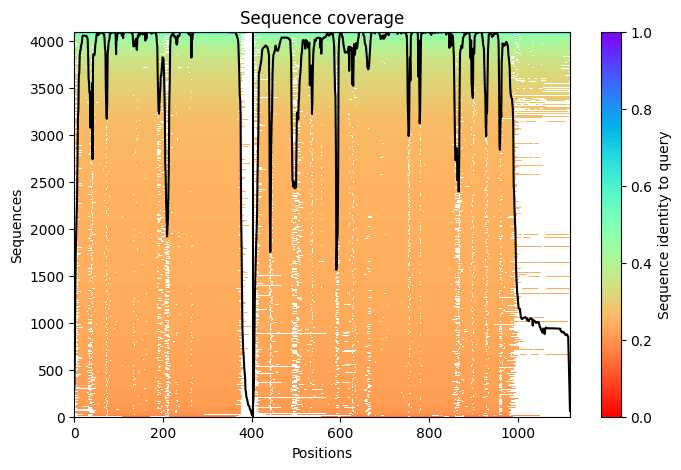

GC 5474


In [ ]:
#@title prep_inputs
jobname = "TestA-B" #@param {type:"string"}
copies = 1
#@markdown **MSA options**
msa_method = "mmseqs2" #@param ["mmseqs2","single_sequence", "custom_fas", "custom_a3m", "custom_sto"]
pair_mode = "paired" #@param ["unpaired_paired","paired","unpaired"] {type:"string"}
#@markdown filtering options
cov = 50 #@param ["0", "25", "50", "75", "90", "99"] {type:"raw"}
id = 99 #@param ["90", "95" "100"] {type:"raw"}
qid = 0 #@param ["0", "10", "15", "20", "30"] {type:"raw"}
do_not_filter = False #@param {type:"boolean"}
sequence = query_sequence
#@markdown ----
#@markdown **Templates options**
template_mode = "none" #@param ["none", "mmseqs2", "custom"] {type:"string"}
use_templates = template_mode in ["mmseqs2","custom"]
pdb = "" #@param {type:"string"}
chain = "A" #@param {type:"string"}
rm_template_seq = False #@param {type:"boolean"}
propagate_to_copies = True #@param {type:"boolean"}
do_not_align = False #@param {type:"boolean"}
rm_sidechain = rm_sequence = rm_template_seq

# filter options
sequence = sequence.upper()
sequence = re.sub("[^A-Z:/()]", "", sequence.upper())
sequence = re.sub("\(",":(", sequence)
sequence = re.sub("\)","):", sequence)
sequence = re.sub(":+",":",sequence)
sequence = re.sub("/+","/",sequence)
sequence = re.sub("^[:/]+","",sequence)
sequence = re.sub("[:/]+$","",sequence)
jobname = re.sub(r'\W+', '', jobname)

# process sequence
sequences = sequence.split(":")
u_sequences = predict.get_unique_sequences(sequences)
u_cyclic = [x.startswith("(") for x in u_sequences]
u_sub_lengths = [[len(y) for y in x.split("/")] for x in u_sequences]
u_sequences = [x.replace("(","").replace(")","").replace("/","") for x in u_sequences]
if len(sequences) > len(u_sequences):
  print("WARNING: use copies to define homooligomers")
u_lengths = [len(x) for x in u_sequences]
sub_seq = "".join(u_sequences)
seq = sub_seq * copies

jobname = f"{jobname}_{predict.get_hash(seq)[:5]}"
def check(folder): return os.path.exists(folder)
if check(jobname):
  n = 0
  while check(f"{jobname}_{n}"): n += 1
  jobname = f"{jobname}_{n}"

print("jobname",jobname)
print(f"length={u_lengths} copies={copies}")

input_opts = {"sequence":u_sequences,
              "copies":copies,
              "msa_method":msa_method,
              "pair_mode":pair_mode,
              "do_not_filter":do_not_filter,
              "cov":cov,
              "id":id,
              "template_mode":template_mode,
              "propagate_to_copies":propagate_to_copies}

def run_mmseqs2_wrapper(*args, **kwargs):
  kwargs['user_agent'] = "colabdesign/gamma"
  return run_mmseqs2(*args, **kwargs)

##################
# GET MSA
##################
os.makedirs(jobname, exist_ok=True)

Ls = [len(x) for x in u_sequences]
if msa_method == "mmseqs2":
  msa, deletion_matrix = predict.get_msa(u_sequences, jobname,
    mode=pair_mode,
    cov=cov, id=id, qid=qid, max_msa=4096,
    do_not_filter=do_not_filter,
    mmseqs2_fn=run_mmseqs2_wrapper,
    hhfilter_fn=run_hhfilter)

elif msa_method == "single_sequence":
  with open(f"{jobname}/msa.a3m","w") as a3m:
    a3m.write(f">{jobname}\n{sub_seq}\n")
  msa, deletion_matrix = predict.parse_a3m(f"{jobname}/msa.a3m")

else:
  msa_format = msa_method.split("_")[1]
  print(f"upload {msa_method}")
  msa_dict = files.upload()
  lines = []
  for k,v in msa_dict.items():
    lines += v.decode().splitlines()
  input_lines = []
  for line in lines:
    line = line.replace("\x00","")
    if len(line) > 0 and not line.startswith('#'):
      input_lines.append(line)
  with open(f"{jobname}/msa.{msa_format}","w") as msa:
    msa.write("\n".join(input_lines))
  if msa_format != "a3m":
    os.system(f"perl hhsuite/scripts/reformat.pl {msa_format} a3m {jobname}/msa.{msa_format} {jobname}/msa.a3m")
  if do_not_filter:
    os.system(f"hhfilter -qid 0 -id 100 -cov 0 -i {jobname}/msa.a3m -o {jobname}/msa.filt.a3m")
  else:
    os.system(f"hhfilter -qid {qid} -id {id} -cov {cov} -i {jobname}/msa.a3m -o {jobname}/msa.filt.a3m")
  msa, deletion_matrix = predict.parse_a3m(f"{jobname}/msa.filt.a3m")

if len(msa) > 1:
  predict.plot_msa(msa, Ls)
  plt.savefig(f"{jobname}/msa_feats.png", dpi=200, bbox_inches='tight')
  plt.show()

##################
if use_templates:
  print("aligning template")
  template_msa = f"{jobname}/msa.a3m"
  if template_mode == "mmseqs2":
    predict.get_msa(u_sequences, jobname,
      mode="unpaired",
      mmseqs2_fn=run_mmseqs2_wrapper,
      do_not_filter=True,
      do_not_return=True,
      output_a3m=f"{jobname}/msa_tmp.a3m")
    template_msa = f"{jobname}/msa_tmp.a3m"
    if not propagate_to_copies and copies > 1:
      new_msa = []
      with open(template_msa, "r") as handle:
        for line in handle:
          if not line.startswith(">"):
            new_msa.append(line.rstrip())
      with open(template_msa, "w") as handle:
        for n,seq in enumerate(new_msa):
          handle.write(f">{n}\n{seq*copies}\n")

    templates = {}
    print("ID\tpdb\tcid\tevalue")
    for line in open(f"{jobname}/msa/_env/pdb70.m8","r"):
      p = line.rstrip().split()
      M,target_id,qid,e_value = p[0],p[1],p[2],p[10]
      M = int(M)
      if M not in templates:
        templates[M] = []
      if len(templates[M]) < 4:
        print(f"{int(M)}\t{target_id}\t{qid}\t{e_value}")
        templates[M].append(target_id)
    if len(templates) == 0:
      use_templates = False
      print("ERROR: no templates found...")
    else:
      Ms = sorted(list(templates.keys()))
      pdbs,chains = [],[]
      for M in Ms:
        for n,target_id in enumerate(templates[M]):
          pdb_id,chain_id = target_id.split("_")
          if len(pdbs) < n+1:
            pdbs.append([])
            chains.append([])
          pdbs[n].append(pdb_id)
          chains[n].append(chain_id)
      print(pdbs)
  else:
    pdbs,chains = [pdb],[chain]

if use_templates:
  input_opts.update({"pdbs":pdbs, "chains":chains})
  batches = []
  for pdb,chain in zip(pdbs,chains):
    query_seq = "".join(u_sequences)
    batch = predict.get_template_feats(pdb, chain,
      query_seq=query_seq,
      query_a3m=template_msa,
      copies=copies,
      propagate_to_copies=propagate_to_copies,
      use_seq=not rm_sequence,
      get_pdb_fn=get_pdb,
      align_fn=run_do_not_align if do_not_align else run_hhalign)
    batches.append(batch)

  # for display
  plt.figure(figsize=(3*len(batches),3))
  for n,batch in enumerate(batches):
    plt.subplot(1,len(batches),n+1)
    plt.title(f"template features {n+1}")
    dgram = batch["dgram"].argmax(-1).astype(float)
    dgram[batch["dgram"].sum(-1) == 0] = np.nan
    Ln = dgram.shape[0]
    plt.imshow(dgram, extent=(0, Ln, Ln, 0))
    predict.plot_ticks(Ls * copies)
  plt.savefig(f"{jobname}/template_feats.png", dpi=200, bbox_inches='tight')
  plt.show()
else:
  batches = [None]

################
print("GC",gc.collect())

In [ ]:
# IMPORTANT, only tested using PYTHON 3!
import numpy as np
import matplotlib.pylab as plt
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from scipy.special import logsumexp
import pandas as pd
# NOTE: tensorflow is only needed for the GREMLIN/MRF backend (opt_adam + GREMLIN()).
# This notebook swaps that stage out, so the TF import/setup has been dropped.

In [ ]:
################
# note: if you are modifying the alphabet
# make sure last character is "-" (gap)
################
alphabet = "ARNDCQEGHILKMFPSTWYV-"
states = len(alphabet)

# map amino acids to integers (A->0, R->1, etc)
a2n = dict((a,n) for n,a in enumerate(alphabet))
aa2int = lambda x: a2n.get(x,a2n['-'])

In [ ]:
#@title Convert the MSA results into a co-evolution input
print("jobname",jobname)
filename  = f'{jobname}/msa.a3m'
def parse_a3m(filename):
    names, seqs = [], []
    current_seq = ""

    with open(filename, "r") as file:
        for line in file:
            line = line.rstrip()

            if line.startswith(">"):
                if current_seq:
                    # Remove lowercase letters from the sequence
                    current_seq = ''.join([char if char.isupper() or char == '-' else '' for char in current_seq])
                    if current_seq.strip():  # Check if the current sequence is not empty
                        seqs.append(current_seq)
                    current_seq = ""
                names.append(line[1:])
            else:
                current_seq += line

    if current_seq:
        # Remove lowercase letters from the sequence
        current_seq = ''.join([char if char.isupper() or char == '-' else '' for char in current_seq])
        if current_seq.strip():  # Check if the last sequence is not empty
            seqs.append(current_seq)

    return names, seqs
names, seqs = parse_a3m(filename)


def filt_gaps(msa, gap_cutoff=0.5):
  '''filters alignment to remove gappy positions'''
  frac_gaps = np.mean((msa == states-1).astype(float),0)
  non_gaps = np.where(frac_gaps < gap_cutoff)[0]
  return msa[:,non_gaps], non_gaps

def get_eff(msa, eff_cutoff=0.8):
  '''compute effective weight for each sequence'''
  msa_sm = 1.0 - squareform(pdist(msa,"hamming"))
  msa_w = (msa_sm >= eff_cutoff).astype(float)
  msa_w = 1.0/np.sum(msa_w,-1)
  return msa_w

def str2int(x):
  '''convert a list of strings into list of integers'''
  # Example: ["ACD","EFG"] -> [[0,4,3], [6,13,7]]
  if x.dtype.type is np.str_:
    if x.ndim == 0: return np.array([aa2int(aa) for aa in x])
    else: return np.array([[aa2int(aa) for aa in seq] for seq in x])
  else:
    return x

def split_train_test(seqs, frac_test=0.1):
  # shuffle data
  x = np.copy(seqs)
  np.random.shuffle(x[1:])

  # fraction of data used for testing
  split = int(len(x) * (1.0-frac_test))

  # split training/test datasets
  return x[:split], x[split:]

def mk_msa(seqs, gap_cutoff=0.5, eff_cutoff=0.8):
  '''converts list of sequences to MSA (Multiple Sequence Alignment)'''
  # =============================================================================
  # The function takes a list of sequences (strings) and returns a (dict)ionary
  # containing the following:
  # =============================================================================
  # BEFORE GAP REMOVAL
  # -----------------------------------------------------------------------------
  # msa_ori   msa
  # ncol_ori  number of columns
  # -----------------------------------------------------------------------------
  # AFTER GAP REMOVAL
  # By default, columns with ≥ 50% gaps are removed. This makes things a
  # little complicated, as we need to keep track of which positions were removed.
  # -----------------------------------------------------------------------------
  # msa       msa
  # ncol      number of columns
  # v_idx     index of positions kept
  # -----------------------------------------------------------------------------
  # weights   weight for each sequence (based on sequence identity)
  # nrow      number of rows (sequences)
  # neff      number of effective sequences sum(weights)
  # =============================================================================

  msa_ori = str2int(seqs)

  # remove positions with more than > 50% gaps
  msa, v_idx = filt_gaps(msa_ori)

  # compute effective weight for each sequence
  msa_weights = get_eff(msa, eff_cutoff)

  return {"msa_ori":msa_ori,
          "msa":msa,
          "weights":msa_weights,
          "neff":np.sum(msa_weights),
          "v_idx":v_idx,
          "nrow":msa.shape[0],
          "ncol":msa.shape[1],
          "ncol_ori":msa_ori.shape[1]}

jobname TestAB_ef331


In [ ]:
headers, seqs = parse_a3m(filename)
#@title Number of effective sequences
#@markdown Coevolution is best informed by greater sequence depth. it has been shown to be 90% accurate with at least an effective sequence length vs query sequence ratio of 1 or above.
train_seqs, test_seqs = split_train_test(seqs, frac_test=0.1)

msa = mk_msa(train_seqs, gap_cutoff=0.5, eff_cutoff=0.8)
print("Number of effective sequences", msa["neff"])
print("Length of Query", len(seq))
depthratio = msa["neff"]/len(seq)
print("Query to effective sequence ratio", depthratio)
if(depthratio > 1):
  print('Number of effective vs query sequence length is sufficient! (>1)')
else:
  print('Number of effective vs query sequence length is low! (<1), take results carefully')


Number of effective sequences 2137.7842687880357
Length of Query 1119
Query to effective sequence ratio 1.9104417057980658
Number of effective vs query sequence length is sufficient! (>1)


In [ ]:
#@title Install plmc (EVcouplings coupling-inference engine)
import os
if not os.path.isfile("plmc/bin/plmc"):
    !rm -rf plmc
    !git clone -q https://github.com/debbiemarkslab/plmc.git
    # all-openmp32: single-precision + OpenMP multi-threading - the fastest build
    # plmc's own README recommends; plain `make` builds a slow single-core binary.
    !cd plmc && make all-openmp32 -j$(nproc)
assert os.path.isfile("plmc/bin/plmc"), "plmc did not build - check the log above"
print("plmc binary ready (OpenMP build):", os.path.abspath("plmc/bin/plmc"))

gcc src/lib/twister.c src/lib/lbfgs.c src/plm.c src/inference.c src/weights.c src/main.c -o bin/plmc -fopenmp -std=c99 -lm -O3 -msse4.2 -D USE_FLOAT
src/weights.c: In function ‘ValidateCustomWeightsFile’:
src/weights.c:258:9: warning: argument 1 null where non-null expected []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wnonnull-Wnonnull]8;;]
  258 |         fclose(fp);
      |         ^~~~~~~~~~
In file included from src/weights.c:3:
/usr/include/stdio.h:184:12: note: in a call to function ‘fclose’ declared ‘nonnull’
  184 | extern int fclose (FILE *__stream) __nonnull ((1));
      |            ^~~~~~
plmc binary ready (OpenMP build): /content/plmc/bin/plmc


In [ ]:
#@title Run plmc on the (gap-filtered) MSA
import numpy as np, os, time

def int2str(x):
  '''inverse of str2int: integer-coded MSA array -> array of strings'''
  return np.array(["".join(alphabet[a] for a in row) for row in x])

# same filtered alignment (>=50% gap columns removed) the GREMLIN backend would train on
filtered_seqs = int2str(msa["msa"])

plmc_dir = f"{jobname}/plmc"
os.makedirs(plmc_dir, exist_ok=True)
fasta_path = f"{plmc_dir}/msa.fa"
with open(fasta_path, "w") as f:
    for n, s in enumerate(filtered_seqs):
        f.write(f">seq_{n}\n{s}\n")

ec_path = f"{plmc_dir}/couplings.ec"
L = msa["ncol"]
lambda_e = 0.2 * (L - 1)  # same length-scaled coupling regularisation convention as CCMpred's default (-l 0.2)

t0 = time.perf_counter()
!plmc/bin/plmc -c {ec_path} -le {lambda_e} -lh 0.01 -m 100 {fasta_path}
elapsed = time.perf_counter() - t0
print(f"[plmc] {elapsed:.2f}s  (L={msa['ncol']}, N={msa['nrow']}, Neff={msa['neff']:.1f})")

# EC file columns: RES_I  FOCUS_AI  RES_J  FOCUS_AJ  0  SCORE  (SCORE = APC-corrected Frobenius norm)
ec = np.loadtxt(ec_path, usecols=(0, 2, 5))
res_i = ec[:, 0].astype(int)
res_j = ec[:, 1].astype(int)
if res_i.min() == 1:   # plmc numbers alignment columns from 1
    res_i = res_i - 1
    res_j = res_j - 1

apc_sq = np.zeros((L, L))
apc_sq[res_i, res_j] = ec[:, 2]
apc_sq[res_j, res_i] = ec[:, 2]
raw_sq = apc_sq.copy()  # plmc's -c output doesn't expose a separate pre-APC score
print("plmc matrix shape:", apc_sq.shape, "(should be", L, "x", L, "retained columns)")

3686 valid sequences out of 3686 
948 sites
Effective number of samples: 2137.8	(80% identical neighborhood = 1.000 samples)
iter	time	cond	fx	-loglk	||h||	||e||
1	45.7	420.61	3619525.2	3619287.2	260.4	1.0
2	67.9	778.92	2964388.0	2960074.8	260.4	14.5
3	91.1	552.30	2726871.5	2711432.0	260.4	21.0
4	115.1	316.62	2596342.0	2582890.2	260.4	20.4
5	139.9	325.95	2508941.5	2497381.5	260.4	20.0
6	165.7	247.11	2419167.5	2405416.8	260.4	21.4
7	192.5	226.13	2126078.2	2091651.4	260.3	28.7
8	219.3	295.18	1972840.2	1868749.1	260.3	35.7
9	246.0	268.12	1871914.4	1729419.1	260.3	39.9
10	272.6	191.32	1810024.8	1669073.1	260.3	39.9
11	299.1	197.93	1739134.4	1604107.2	260.3	39.9
12	325.5	162.98	1682865.5	1535906.6	260.3	41.3
13	352.0	155.17	1605909.1	1432754.1	260.3	44.1
14	378.5	171.40	1543116.2	1345905.9	260.3	46.3
15	405.1	124.39	1491864.9	1280579.4	260.3	47.5
16	431.9	119.22	1475788.0	1270610.8	260.3	47.1
17	458.5	83.95	1457997.9	1256075.0	260.3	47.0
18	485.2	84.42	1433319.0	1225279.2	260.3	47.6
19	511.

### Common coupling-matrix format

This is the hand-off point back into the unmodified CoEVFold code. `build_mtx`
plays the same role as the original `get_mtx(mrf)`: it takes a square L×L
raw/APC coupling-score matrix (L = number of gap-filtered columns) and turns
it into the same `mtx` dict (`i`, `j`, `raw`, `apc`, `zscore`, `len`) that the
rest of the notebook (from the `i_aa`/`j_aa`/`pd_mtx` cell onward) already
expects -- so nothing below this point needs to change between backends.

`zscore` is computed with the *same* Box-Cox + standardisation step GREMLIN
used (`normalize()`), so the `GREM_threshold` cutoffs used later in the
notebook stay comparable across backends.

Some backends (PyCoM) can't populate every entry of the matrix; those cells
are left as `NaN` and are simply dropped here rather than passed downstream.


In [ ]:
#@title Common coupling-matrix format + plot (shared logic, same output shape as GREMLIN's get_mtx)
def normalize(x):
  x = stats.boxcox(x - np.amin(x) + 1.0)[0]
  x_mean = np.mean(x)
  x_std = np.std(x)
  return((x-x_mean)/x_std)

def build_mtx(raw_sq, apc_sq, v_idx, len_ori):
  '''convert a square LxL raw/APC coupling-score matrix into CoEVFold's common
     mtx format (same keys as GREMLIN's get_mtx(), so downstream is unchanged)
     raw_sq, apc_sq : (L,L) symmetric numpy arrays, zero diagonal
     v_idx           : maps column n of raw_sq/apc_sq back to its position in
                        the FULL (pre gap-filtering) sequence numbering
     len_ori         : full sequence length (mrf["len"] equivalent)
  '''
  raw_full = squareform(raw_sq, checks=False)
  apc_full = squareform(apc_sq, checks=False)
  i_full, j_full = np.triu_indices_from(raw_sq, k=1)

  # some backends (PyCoM) can't populate every pair -> those are NaN; drop them
  keep = ~np.isnan(apc_full)

  mtx = {
         "i": np.asarray(v_idx)[i_full[keep]],
         "j": np.asarray(v_idx)[j_full[keep]],
         "raw": raw_full[keep],
         "apc": apc_full[keep],
         "zscore": normalize(apc_full[keep]),
         "len": len_ori
  }
  return mtx

def plot_mtx(mtx, method_name="GREMLIN"):
  '''plot the mtx'''
  plt.figure(figsize=(5,5))
  for n, key in enumerate(["zscore"]):

    # create empty mtx
    m = np.ones((mtx["len"],mtx["len"])) * np.nan

    # populate
    m[mtx["i"],mtx["j"]] = mtx[key]
    m[mtx["j"],mtx["i"]] = m[mtx["i"],mtx["j"]]

    #plot
    plt.plot
    plt.title(f"Co-Evolution Matrix ({method_name}_ZScore)")
    if key == "zscore": plt.imshow(m, cmap='Blues', vmin=0.5, vmax=2)
    else: plt.imshow(m, cmap='Blues')
    plt.grid(False)
    if ':' in query_sequence:
     plt.xlabel("Protein Amino acids")
  plt.savefig(f'co-ev{jobname}.png')
  plt.show()
  print()


In [ ]:
#@title Export coupling matrix to CSV (all pairs, zscore > 2)
import pandas as pd
from google.colab import files

zscore_cutoff = 2
method_name = "plmC"  #@param {type:"string"}  # set to match this notebook's backend: "GREMLIN", "CCMpred", "plmc" or "PyCoM"

export_df = pd.DataFrame({
    "i": mtx["i"],
    "j": mtx["j"],
    "raw": mtx["raw"],
    "apc": mtx["apc"],
    "zscore": mtx["zscore"],
})
export_df = export_df[export_df["zscore"] > zscore_cutoff]
export_df = export_df.sort_values("zscore", ascending=False).reset_index(drop=True)

csv_path = f"{jobname}_{method_name}_zscore_gt_{zscore_cutoff}.csv"
export_df.to_csv(csv_path, index=False)  # no float_format - full precision, unrounded

print(f"{len(export_df)} / {len(mtx['i'])} total pairs have zscore > {zscore_cutoff}")
print(f"written to {csv_path}")
files.download(csv_path)

9529 / 448878 total pairs have zscore > 2
written to FtsW-pbpB_GREMLIN_zscore_gt_2.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

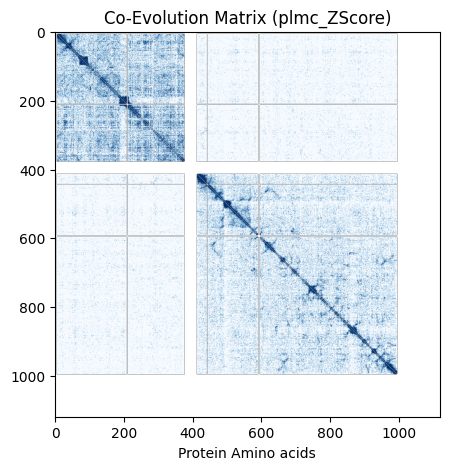

In [ ]:
query_sequence = sequence
mtx = build_mtx(raw_sq, apc_sq, msa["v_idx"], msa["ncol_ori"])
plot_mtx(mtx, method_name="plmc")


In [ ]:
######################################################################################
# WARNING - WARNING - WARNING
######################################################################################
# - the index starts at 0
# - the "first" position is 0
# - in bioinformatics, the first position of a sequence is often "1"
#   for this index use i_aa and j_aa!

# adding amino acid to index+1 this is done again in the next step #message from Chris LB Graham
seq = seqs[0]
mtx["i_aa"] = [f"{seq[i]}_{i+1}" for i in mtx["i"]]
mtx["j_aa"] = [f"{seq[j]}_{j+1}" for j in mtx["j"]]

# load mtx into pandas dataframe
pd_mtx = pd.DataFrame(mtx,columns=["i","j","raw","apc","zscore","i_aa","j_aa"])
coev_mtx = pd.DataFrame(mtx,columns=["i","j","zscore"])

In [ ]:
!python -m pip install --upgrade pip
!pip install tr-rosetta-pytorch
!apt-get install pymol

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 83.4 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 MB 92.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [tr-rosetta-pytorch]
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  apbs apbs-data at-spi2-common at-spi2-core fonts-mathjax
  gsettings-desktop-schemas libamd3 libapbs3t64 libatk-bridge2.0-0t64
  libatk1.0-0t64 libatspi2.0-0t64 libcamd3 libccolamd3 libcholmod5 libcolamd3
  libdouble-conversion3 libegl-dev libevdev2 libfetk1.9t64 libgl-dev
  libgl1-mesa-dev libgles-dev libgles1 libglew2.2 libglu1-mesa
  libglu1-mesa-dev libglut-dev libglut3.12 libglvnd-core-dev libglvnd-dev
  libglx-dev libgtk-3-0t64 libgtk-3-bin libgtk-3-common libgudev-1.0-0
 

In [ ]:
!pip install biopython matplotlib numpy


In [ ]:
from Bio.PDB import PDBParser, PDBIO, Select

# Parse original structure
parser = PDBParser(QUIET=True)
structure = parser.get_structure("structure", pdb_filename)

# Renumber residues per chain
for model in structure:
    for chain in model:
        new_id = 1
        for residue in chain.get_residues():
            if residue.id[0] == ' ':  # Only standard residues (ignore hetero/water)
                residue.id = (' ', new_id, ' ')
                new_id += 1

# Save to new file
renumbered_filename = pdb_filename
io = PDBIO()
io.set_structure(structure)
io.save(renumbered_filename)
print(f"Saved renumbered PDB: {renumbered_filename}")

Saved renumbered PDB: FtsW-pbpB.pdb


In [ ]:
# NOTE: this was `GREM_threshold` in the original GREMLIN notebook. Renamed to
# zscore_threshold because it thresholds the common `zscore` column produced by
# build_mtx() above, whatever backend generated the underlying coupling matrix.
# It's a per-run z-score (Box-Cox normalised, mean 0 / std 1 within THIS run's
# own score distribution) rather than an absolute coupling strength, so a cutoff
# of e.g. 2 selects "the top tail of this run's own scores" in every backend -
# but different algorithms produce differently-shaped raw-score distributions,
# so the same numeric cutoff isn't guaranteed to pick an equally-sized or
# equally-precise set of pairs across GREMLIN vs CCMpred vs plmc vs PyCoM.
# Treat cross-backend comparisons at a fixed threshold as a starting point to
# eyeball, not as a calibrated apples-to-apples precision comparison.


In [ ]:
import numpy as np
import pandas as pd

# Threshold for filtering coevolving residues
zscore_threshold = 2  # @param

# Load your matrix, assuming 'i', 'j', 'zscore' columns exist
new_df = pd_mtx[['i', 'j', 'zscore']].copy()

# Parse query sequence into individual job sequences
job_seqs = query_sequence.split(':')
job_boundaries = np.cumsum([0] + [len(seq) for seq in job_seqs])  # Get index boundaries per job

# Container for final results
results = []

# Loop over all unique inter-job pairs (i < j)
for i in range(len(job_seqs)):
    for j in range(i+1, len(job_seqs)):
        start_i, end_i = job_boundaries[i], job_boundaries[i+1]
        start_j, end_j = job_boundaries[j], job_boundaries[j+1]

        # Filter interactions between job_i and job_j
        df = new_df[
            (new_df['i'] >= start_i) & (new_df['i'] < end_i) &
            (new_df['j'] >= start_j) & (new_df['j'] < end_j) &
            ((new_df['j'] - new_df['i']) > 5) &
            (new_df['zscore'] > zscore_threshold)
        ].copy()

        if df.empty:
            continue

        # Adjust residue indices to be local to their respective jobs
        df['Aaa-B'] = df['i'] - start_i + 1  # 1-based indexing
        df['A-Baa'] = df['j'] - start_j + 1
        df['A-B-Score'] = df['zscore']

        # Select and reorder columns
        df = df[['Aaa-B', 'A-Baa', 'A-B-Score']]

        job_pair_label = f"{i+1}-{j+1}"
        df.columns = [f"{job_pair_label}-Aaa-B", f"{job_pair_label}-A-Baa", f"{job_pair_label}-A-B-Score"]

        # Store result
        results.append(df)

# Concatenate all inter-job interactions
if results:
    final_df = pd.concat(results, axis=1)
    final_df.to_csv('sorted_file.csv', sep=' ', index=False)
    print(final_df)
else:
    print("No inter-job interactions above threshold.")


        1-2-Aaa-B  1-2-A-Baa  1-2-A-B-Score
12604          19         25       2.016570
16741          23        441       2.458671
19463          26        379       2.036198
32227          40        270       2.013683
38717          47        397       2.134705
...           ...        ...            ...
268793        355        208       2.015771
270104        357        322       2.026040
275984        367        277       2.171452
276098        367        391       2.234023
276947        369         63       2.284322

[102 rows x 3 columns]


In [ ]:
import pandas as pd
from google.colab import files
!curl -L -O "https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-$(uname)-$(uname -m).sh"
!bash Miniforge3-Linux-x86_64.sh -b -p /content/mambaforge -u

# Force PATH update in the shell
!export PATH=/content/mambaforge/bin:$PATH

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  118M  100  118M    0     0   116M      0  0:00:01  0:00:01 --:--:--  365M
PREFIX=/content/mambaforge
Unpacking bootstrapper...
Unpacking payload...
Extracting ca-certificates-2026.7.22-hbd8a1cb_0.conda
Extracting libgomp-16.2.0-he0feb66_4.conda
Extracting libzlib-1.3.2-h25fd6f3_3.conda
Extracting nlohmann_json-abi-3.12.0-h0f90c79_2.conda
Extracting pybind11-abi-11-hc364b38_1.conda
Extracting python_abi-3.14-9_cp314.conda
Extracting tzdata-2026c-h151e31d_0.conda
Extracting _openmp_mutex-4.5-20_gnu.conda
Extracting zstd-1.5.7-hb78ec9c_7.conda
Extracting ld_impl_linux-64-2.46.1-default_hbd61a6d_102.conda
Extracting libgcc-16.2.0-ha9f2e26_4.conda
Extracting bzip2-1.0.8-hda65

In [ ]:
from Bio.PDB import PDBParser, PDBIO, Select

# Define selector that includes only standard amino acids
class OnlyAminoAcids(Select):
    def accept_residue(self, residue):
        return residue.id[0] == ' '  # Only accept standard residues (no HETATM)

# Parse the structure
parser = PDBParser(QUIET=True)
structure = parser.get_structure("structure", pdb_filename)

# Save only amino acids to new PDB
io = PDBIO()
io.set_structure(structure)
io.save(pdb_filename, OnlyAminoAcids())

print(f"Saved cleaned PDB without non-amino acids: {pdb_filename}")

Saved cleaned PDB without non-amino acids: FtsW-pbpB.pdb


In [ ]:
from collections import defaultdict
from Bio.Data.IUPACData import protein_letters_3to1

# ---------------------------
# Extract sequences per TRUE chain (ignoring chain breaks)
# ---------------------------
def get_chain_sequence(chain):
    seq = ""
    for res in chain.get_residues():
        if res.id[0] != " ":   # Skip ligands, waters
            continue
        aa = protein_letters_3to1.get(res.resname.capitalize(), "X")
        seq += aa
    return seq

sequence_to_chains = defaultdict(list)
chain_sequences = {}

for model in structure:
    for chain in model:
        seq = get_chain_sequence(chain)
        if seq:
            chain_sequences[chain.id] = seq
            sequence_to_chains[seq].append(chain.id)

# ---------------------------
# Build jobs based on unique sequences
# ---------------------------
jobs = []
for i, (seq, chains) in enumerate(sequence_to_chains.items(), start=1):
    job_id = f"Job_{i}"
    jobs.append((job_id, seq, chains))

# ---------------------------
# Build job_info (NEEDED for PyMOL code)
# ---------------------------
job_info = [
    {
        "job_id": job_id,
        "sequence_length": len(seq),
        "chains": chains
    }
    for job_id, seq, chains in jobs
]

print("Job Info Rebuilt:")
for j in job_info:
    print(j)

import pandas as pd
from google.colab import files
import random
import os
import sys

# ---------------------------
# PyMOL installation environment fixes
# ---------------------------
os.environ['PATH'] = f"/content/mambaforge/bin:{os.environ['PATH']}"
sys.path.append('/content/mambaforge/lib/python3.10/site-packages')

# Clear PYTHONPATH to prevent conflicts
if 'PYTHONPATH' in os.environ:
    del os.environ['PYTHONPATH']

!which mamba
!mamba --version
!mamba install -c conda-forge pymol-open-source -y
!mamba install -c conda-forge tqdm -y

# ---------------------------
# Parameters
# ---------------------------
zscore_threshold = 2.5     #@param Interaction score cutoff
Angstrom_cutoff = 30     #@param Distance measurement cutoff
jobname = os.path.splitext(pdb_filename)[0]  # Name from uploaded PDB

# ---------------------------
# Load GREMLIN output
# ---------------------------
df = pd.read_csv('sorted_file.csv', sep=' ')

# ---------------------------
# PyMOL script assembly
# ---------------------------
color_list = [
    "red", "blue", "green", "orange", "purple", "cyan", "yellow",
    "magenta", "lime", "salmon", "deepsalmon", "tv_blue", "marine",
    "hotpink", "wheat", "forest", "chocolate", "slate"
]

pym_script = []
pym_script.append(f"cmd.load('{pdb_filename}')")
pym_script.append('cmd.color("gray90")')
pym_script.append('cmd.cartoon("automatic")')
pym_script.append('cmd.set("dash_radius", 0.4)')
pym_script.append('cmd.bg_color("white")')

# ---------------------------
# Extract job pair prefixes
# ---------------------------
job_pairs = set()
for col in df.columns:
    if col.endswith('-A-B-Score'):
        pair = col.replace('-A-B-Score', '')
        job_pairs.add(pair)

job_pair_colors = {
    pair: color_list[i % len(color_list)]
    for i, pair in enumerate(sorted(job_pairs))
}

# ---------------------------
# Map job IDs → chain list from new job_info format
# ---------------------------
# job_info looks like: { "job_id": "Job_1", "sequence_length": XX, "chains": ["A","C"] }
job_id_to_chains = {
    entry["job_id"]: entry["chains"]
    for entry in job_info
}

# ---------------------------
# Generate PyMOL measurements
# ---------------------------
for pair in job_pairs:

    # GREMLIN columns
    A_col = f"{pair}-Aaa-B"
    B_col = f"{pair}-A-Baa"
    score_col = f"{pair}-A-B-Score"

    # Skip missing columns
    if not all(col in df.columns for col in [A_col, B_col, score_col]):
        continue

    # Filter hits
    subset = df[[A_col, B_col, score_col]].dropna()
    subset = subset[subset[score_col] > zscore_threshold]

    # Parse job IDs (example: "1-2" → Job_1 and Job_2)
    job1_idx, job2_idx = pair.split('-')
    job1_id = f"Job_{job1_idx}"
    job2_id = f"Job_{job2_idx}"

    chain_set_1 = job_id_to_chains.get(job1_id, [])
    chain_set_2 = job_id_to_chains.get(job2_id, [])

    color = job_pair_colors[pair]

    # Build distance commands
    for _, row in subset.iterrows():
        resA = int(row[A_col])
        resB = int(row[B_col])

        for c1 in chain_set_1:
            for c2 in chain_set_2:
                label = f"d{resA}-{resB}_{c1}{c2}_{pair}"

                pym_script.append(
                    f'cmd.distance("{label}", '
                    f'"resi {resA} and name CA and chain {c1}", '
                    f'"resi {resB} and name CA and chain {c2}", '
                    f'{Angstrom_cutoff})'
                )
                pym_script.append(
                    f'cmd.set("dash_color", "{color}", "{label}")'
                )

# ---------------------------
# Save PyMOL session file
# ---------------------------
pym_script.append(f'cmd.save("{jobname}.pse")')

# Write script to disk
with open("script.py", "w") as out:
    out.write("\n".join(pym_script))

# Run PyMOL headless
!pymol -cq script.py

# Download session
files.download(f"{jobname}.pse")


Job Info Rebuilt:
{'job_id': 'Job_1', 'sequence_length': 403, 'chains': ['A']}
{'job_id': 'Job_2', 'sequence_length': 716, 'chains': ['B']}
/content/mambaforge/bin/mamba
2.9.0
[+] 0.0s
Fetch Shard Index for conda-forge/linux-64                                                ✔ Done (0.1 sec)
Fetch Shard Index for conda-forge/noarch                                                  ✔ Done (0.1 sec)
Fetching and Parsing Packages' Shards                                                     ✔ Done (4.6 sec)

Pinned packages:

  - python=3.14

Resolving Environment                                                                     ✔ Done (0.8 sec)

Transaction

  Prefix: /content/mambaforge

  Updating specs:

   - pymol-open-source


  Package                       Version  Build                 Channel          Size
──────────────────────────────────────────────────────────────────────────────────────
  Install:
───────────────────────────────────────────────────────────────────────────────

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>